# 🧬 Notebook 2 — Build a DNA Transformer and Compare Tokenizers

In Notebook 1, you **used and fine-tuned a pretrained Transformer**: DNABERT.

Now we open the black box.

> **Can we build the essential pieces of a Transformer ourselves, train it from scratch on the same CTCF problem, and test how the DNA representation changes performance and computation?**

This notebook is intentionally more hands-on than Notebook 1.

You will repeatedly follow:

**inspect → code → check shapes → train → graph → modify → compare**

### By the end of Notebook 2, you should be able to

- Explain and implement five DNA representations:
  - single nucleotide,
  - one-hot,
  - overlapping 6-mer,
  - non-overlapping 6-mer,
  - BPE.
- Use Python/pandas to explore token counts, vocabulary sizes, and computational trade-offs.
- Explain tensor dimensions such as **batch × tokens × embedding**.
- Code the essential steps of self-attention:
  - Q,
  - K,
  - V,
  - attention scores,
  - softmax,
  - weighted sum.
- Build:
  - an attention head,
  - multi-head attention,
  - a feed-forward network,
  - a Transformer block,
  - a complete DNA classifier.
- Train the same core Transformer with all five representations.
- Evaluate models with:
  - loss,
  - accuracy,
  - precision,
  - recall,
  - specificity,
  - F1,
  - AUROC,
  - AUPRC,
  - confusion matrices,
  - ROC and precision–recall curves.
- Modify architecture and training parameters in a controlled experiment.
- Save your results so Notebook 3 can later scale the experiments with HPC.

### Notebook markers

| Marker | Meaning |
|---|---|
| 🔒 **RUN ONLY** | Infrastructure; run it without memorizing it |
| 👀 **READ** | Important code; understand what each main line does |
| ✏️ **EDIT ME** | Change a value and observe the effect |
| 🔲 **TRY IT** | Small coding/data exploration activity |
| 🧠 **BUILD IT** | Essential Transformer code you should understand |
| ✅ **CHECKPOINT** | Stop and explain the idea before continuing |

## Roadmap

```mermaid
flowchart LR
    A["Same CTCF dataset"] --> B["Explore 5 representations"]
    B --> C["Q / K / V"]
    C --> D["Attention Head"]
    D --> E["Multi-Head Attention"]
    E --> F["Transformer Block"]
    F --> G["DNA Classifier"]
    G --> H["Train 5 tokenizers"]
    H --> I["Evaluate + graph"]
    I --> J["Change model parameters"]
```

Notebook 1 asked:

> **How can we adapt a pretrained DNA model?**

Notebook 2 asks:

> **What happens when we build the model ourselves and make the representation part of the experiment?**

# 1. Load the Same CTCF Dataset

A fair comparison begins with the same data.

We will use the same cleaning logic as Notebook 1:

- expected sequence length,
- only `A/C/G/T`,
- remove sequences with conflicting labels,
- keep one copy of each exact DNA sequence,
- fixed stratified 80/20 train/validation split.

That keeps the biological problem constant while we change the **representation** and later the **Transformer architecture**.

In [2]:
# 🔒 RUN ONLY — imports, paths, reproducibility, and metrics
import os
import time
import json
import itertools
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

PROJECT_DIR = Path(os.path.expanduser("~"))
DATA_DIR = PROJECT_DIR / "ctcf_k562_example"
RESULTS_DIR = PROJECT_DIR / "notebook2_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device      :", device)
print("Data        :", DATA_DIR)
print("Results     :", RESULTS_DIR)

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

Device      : cuda
Data        : /global/homes/j/jrios/ctcf_k562_example
Results     : /global/homes/j/jrios/notebook2_results
GPU         : NVIDIA A100-SXM4-40GB


In [3]:
# 🔒 RUN ONLY — load and clean exactly one copy of each valid sequence
with open(DATA_DIR / "seqs.txt") as f:
    raw_seqs = [
        line.strip().upper()
        for line in f
        if line.strip()
    ]

with open(DATA_DIR / "labels.txt") as f:
    raw_labels = [
        int(line.strip())
        for line in f
        if line.strip()
    ]

assert len(raw_seqs) == len(raw_labels)

df = pd.DataFrame({
    "sequence": raw_seqs,
    "label": raw_labels,
})

df["label_name"] = df["label"].map({
    0: "Background",
    1: "Binding",
})

df["length"] = df["sequence"].apply(len)

expected_length = df["length"].mode().iloc[0]

df["length_ok"] = (
    df["length"] == expected_length
)

df["valid_dna"] = df["sequence"].apply(
    lambda seq: set(seq) <= set("ACGT")
)

labels_per_sequence = (
    df.groupby("sequence")["label"].nunique()
)

conflicting_sequences = set(
    labels_per_sequence[
        labels_per_sequence > 1
    ].index
)

clean_df = df[
    df["length_ok"]
    & df["valid_dna"]
    & ~df["sequence"].isin(
        conflicting_sequences
    )
].copy()

clean_df = (
    clean_df
    .drop_duplicates(
        subset="sequence",
        keep="first",
    )
    .reset_index(drop=True)
)

train_df, val_df = train_test_split(
    clean_df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=clean_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_seqs = train_df["sequence"].tolist()
train_labels = train_df["label"].tolist()
val_seqs = val_df["sequence"].tolist()
val_labels = val_df["label"].tolist()

print(f"Raw rows        : {len(df):,}")
print(f"Clean rows      : {len(clean_df):,}")
print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(val_df):,}")
print()
print(clean_df["label_name"].value_counts())

Raw rows        : 1,813
Clean rows      : 1,813
Training rows   : 1,450
Validation rows : 363

label_name
Background    907
Binding       906
Name: count, dtype: int64


### ✅ CHECKPOINT 1

Why should every tokenizer use:

- the same cleaned sequences,
- the same training rows,
- the same validation rows,
- the same random seed?

Because otherwise we would not know whether a performance difference came from the tokenizer/model or from receiving a different dataset.

# 2. Five Ways to Represent the Same DNA

A Transformer cannot directly process the string:

```text
ACGTGCA...
```

We must convert DNA into numerical input.

In this notebook we compare five representations.

```mermaid
flowchart TD
    A["Raw DNA<br/>200 bases"] --> B["Single nucleotide<br/>1 base = 1 token"]
    A --> C["One-hot<br/>1 base = 1 vector"]
    A --> D["Overlapping 6-mer<br/>stride 1"]
    A --> E["Non-overlapping 6-mer<br/>stride 6"]
    A --> F["BPE<br/>variable-length learned chunks"]
```

The representation can change:

- how many tokens the model processes,
- how large the input vocabulary is,
- how much local context is already inside each token,
- model parameter count,
- training speed,
- and possibly prediction performance.

## 2A. Single-Nucleotide Tokens

The simplest approach is:

```text
A C G T G C A
↓ ↓ ↓ ↓ ↓ ↓ ↓
1 2 3 4 3 2 1
```

We reserve token ID `0` for **padding**, so real DNA bases start at `1`.

### 🧠 BUILD IT

The essential Python idea is a dictionary lookup:

```python
BASE_TO_ID = {
    "A": 1,
    "C": 2,
    "G": 3,
    "T": 4,
}

tokens = [BASE_TO_ID[base] for base in sequence]
```

In [4]:
# 🧠 BUILD IT — single-nucleotide tokenizer
PAD_ID = 0

BASE_TO_ID = {
    "A": 1,
    "C": 2,
    "G": 3,
    "T": 4,
}

SINGLE_NUC_VOCAB_SIZE = 5

def tokenize_single_nucleotide(seq):
    return [
        BASE_TO_ID[base]
        for base in seq
    ]

# ✏️ EDIT ME
DEMO_DNA = train_seqs[0][:24]

print("DNA :", DEMO_DNA)
print("IDs :", tokenize_single_nucleotide(DEMO_DNA))

DNA : TTCAAAAAAAAAGAAATCGATACA
IDs : [4, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 4, 2, 3, 1, 4, 1, 2, 1]


## 2B. One-Hot Encoding

One-hot encoding does not use an integer token ID.

Each base becomes a fixed vector:

```text
A → [1, 0, 0, 0]
C → [0, 1, 0, 0]
G → [0, 0, 1, 0]
T → [0, 0, 0, 1]
```

Single-nucleotide IDs and one-hot encoding contain essentially the same base identity information.

The difference is **how that information enters the neural network**:

```text
integer ID → learned nn.Embedding lookup

one-hot vector → learned nn.Linear projection
```

In [5]:
# 🧠 BUILD IT — one-hot representation
BASE_TO_ONEHOT = {
    "A": [1.0, 0.0, 0.0, 0.0],
    "C": [0.0, 1.0, 0.0, 0.0],
    "G": [0.0, 0.0, 1.0, 0.0],
    "T": [0.0, 0.0, 0.0, 1.0],
}

ONE_HOT_DIM = 4

def tokenize_onehot(seq):
    return [
        BASE_TO_ONEHOT[base]
        for base in seq
    ]

print("DNA:")
print(DEMO_DNA[:8])

print("\nOne-hot:")
for base, vector in zip(
    DEMO_DNA[:8],
    tokenize_onehot(DEMO_DNA[:8]),
):
    print(base, "→", vector)

DNA:
TTCAAAAA

One-hot:
T → [0.0, 0.0, 0.0, 1.0]
T → [0.0, 0.0, 0.0, 1.0]
C → [0.0, 1.0, 0.0, 0.0]
A → [1.0, 0.0, 0.0, 0.0]
A → [1.0, 0.0, 0.0, 0.0]
A → [1.0, 0.0, 0.0, 0.0]
A → [1.0, 0.0, 0.0, 0.0]
A → [1.0, 0.0, 0.0, 0.0]


## 2C. Overlapping 6-mers

A **6-mer** contains six adjacent DNA bases.

With **stride 1**, the window moves one base at a time:

```text
ACGTGCA
ACGTGC
 CGTGCA
```

For a sequence of length `L`:

```text
number of overlapping k-mers = L - k + 1
```

For `L = 200` and `k = 6`:

```text
195 tokens
```

The vocabulary contains every possible A/C/G/T 6-mer:

```text
4^6 = 4,096 possible 6-mers
```

In [6]:
# 🧠 BUILD IT — overlapping 6-mers
K = 6

def build_kmer_vocab(k):
    kmers = (
        "".join(chars)
        for chars in itertools.product(
            "ACGT",
            repeat=k,
        )
    )

    # IDs start at 1 because 0 is PAD.
    return {
        kmer: i + 1
        for i, kmer in enumerate(kmers)
    }

KMER_VOCAB = build_kmer_vocab(K)
KMER_VOCAB_SIZE = len(KMER_VOCAB) + 1

def tokenize_overlap(seq):
    return [
        KMER_VOCAB[
            seq[i:i + K]
        ]
        for i in range(
            len(seq) - K + 1
        )
    ]

demo_overlap_text = [
    DEMO_DNA[i:i + K]
    for i in range(
        len(DEMO_DNA) - K + 1
    )
]

print(demo_overlap_text[:10])
print("Number of tokens:", len(demo_overlap_text))

['TTCAAA', 'TCAAAA', 'CAAAAA', 'AAAAAA', 'AAAAAA', 'AAAAAA', 'AAAAAA', 'AAAAAG', 'AAAAGA', 'AAAGAA']
Number of tokens: 19


## 2D. Non-Overlapping 6-mers

Now move the window by six bases instead of one:

```text
ACGTGC AATTGG ...
```

For a 200-bp sequence:

```text
floor(200 / 6) = 33 complete 6-mers
```

This representation is much shorter, but our implementation **drops the final incomplete chunk**.

For 200 bp and `k=6`, the last **2 bases are not represented**.

That is a real information trade-off.

In [7]:
# 🧠 BUILD IT — non-overlapping 6-mers
def tokenize_nonoverlap(seq):
    return [
        KMER_VOCAB[
            seq[i:i + K]
        ]
        for i in range(
            0,
            len(seq) - K + 1,
            K,
        )
    ]

demo_nonoverlap_text = [
    DEMO_DNA[i:i + K]
    for i in range(
        0,
        len(DEMO_DNA) - K + 1,
        K,
    )
]

print(demo_nonoverlap_text)
print("Number of tokens:", len(demo_nonoverlap_text))

['TTCAAA', 'AAAAAA', 'GAAATC', 'GATACA']
Number of tokens: 4


## 2E. BPE — Let the Data Learn Its Chunks

**BPE (Byte-Pair Encoding)** begins with single characters and repeatedly merges the most common adjacent pair.

Example idea:

```text
A C G T G C A
```

If `G T` is a frequent pair:

```text
A C GT G C A
```

If `A C` is frequent:

```text
AC GT G C A
```

Tokens can therefore have **different lengths**.

Important experimental rule:

> BPE merge rules are learned from the **training set only**.

If we learned the tokenizer from validation DNA too, the validation set would influence the model pipeline before evaluation.

In [8]:
# 🔒 RUN ONLY — train a simple BPE tokenizer on training DNA only
BPE_UNK_ID = 1

def train_bpe(sequences, num_merges=80):
    corpus = [
        list(seq)
        for seq in sequences
    ]

    rules = []

    for _ in range(num_merges):
        pair_counts = collections.Counter()

        for tokens in corpus:
            pair_counts.update(
                zip(
                    tokens[:-1],
                    tokens[1:],
                )
            )

        if not pair_counts:
            break

        best_pair = (
            pair_counts
            .most_common(1)[0][0]
        )

        merged_token = "".join(
            best_pair
        )

        new_corpus = []

        for tokens in corpus:
            new_tokens = []
            i = 0

            while i < len(tokens):
                if (
                    i < len(tokens) - 1
                    and tokens[i] == best_pair[0]
                    and tokens[i + 1] == best_pair[1]
                ):
                    new_tokens.append(
                        merged_token
                    )
                    i += 2
                else:
                    new_tokens.append(
                        tokens[i]
                    )
                    i += 1

            new_corpus.append(
                new_tokens
            )

        corpus = new_corpus
        rules.append(best_pair)

    return rules


def apply_bpe(seq, rules):
    tokens = list(seq)

    for pair in rules:
        merged_token = "".join(pair)
        new_tokens = []
        i = 0

        while i < len(tokens):
            if (
                i < len(tokens) - 1
                and tokens[i] == pair[0]
                and tokens[i + 1] == pair[1]
            ):
                new_tokens.append(
                    merged_token
                )
                i += 2
            else:
                new_tokens.append(
                    tokens[i]
                )
                i += 1

        tokens = new_tokens

    return tokens


BPE_MERGES = 80

print(
    f"Learning {BPE_MERGES} BPE merge rules "
    "from TRAINING DNA only..."
)

BPE_RULES = train_bpe(
    train_seqs,
    num_merges=BPE_MERGES,
)

bpe_tokens_seen = set()

for seq in train_seqs:
    bpe_tokens_seen.update(
        apply_bpe(
            seq,
            BPE_RULES,
        )
    )

# PAD = 0, UNK = 1, real BPE tokens begin at 2.
BPE_VOCAB = {
    token: i + 2
    for i, token in enumerate(
        sorted(bpe_tokens_seen)
    )
}

BPE_VOCAB_SIZE = (
    len(BPE_VOCAB) + 2
)

def tokenize_bpe(seq):
    return [
        BPE_VOCAB.get(
            token,
            BPE_UNK_ID,
        )
        for token in apply_bpe(
            seq,
            BPE_RULES,
        )
    ]

print("BPE vocabulary size:", BPE_VOCAB_SIZE)
print("First 10 merge rules:", BPE_RULES[:10])

Learning 80 BPE merge rules from TRAINING DNA only...
BPE vocabulary size: 86
First 10 merge rules: [('T', 'T'), ('A', 'A'), ('T', 'G'), ('A', 'G'), ('C', 'C'), ('T', 'C'), ('A', 'C'), ('G', 'G'), ('A', 'TT'), ('A', 'T')]


In [9]:
# 🔲 TRY IT — inspect BPE text tokens
bpe_demo_tokens = apply_bpe(
    DEMO_DNA,
    BPE_RULES,
)

print("DNA:")
print(DEMO_DNA)

print("\nBPE tokens:")
print(bpe_demo_tokens)

print("\nCharacters per token:")
print([
    len(token)
    for token in bpe_demo_tokens
])

print(
    "\nNumber of BPE tokens:",
    len(bpe_demo_tokens),
)

DNA:
TTCAAAAAAAAAGAAATCGATACA

BPE tokens:
['TTC', 'AAAA', 'AAAA', 'AGAA', 'ATC', 'G', 'ATAC', 'A']

Characters per token:
[3, 4, 4, 4, 3, 1, 4, 1]

Number of BPE tokens: 8


In [10]:
# 🔒 RUN ONLY — registry used by the rest of the notebook
TOKENIZERS = {
    "single_nucleotide": {
        "fn": tokenize_single_nucleotide,
        "continuous": False,
        "vocab_size": SINGLE_NUC_VOCAB_SIZE,
        "input_dim": None,
        "position_capacity": 200,
    },

    "one_hot": {
        "fn": tokenize_onehot,
        "continuous": True,
        "vocab_size": None,
        "input_dim": ONE_HOT_DIM,
        "position_capacity": 200,
    },

    "overlap_6mer": {
        "fn": tokenize_overlap,
        "continuous": False,
        "vocab_size": KMER_VOCAB_SIZE,
        "input_dim": None,
        "position_capacity": 195,
    },

    "nonoverlap_6mer": {
        "fn": tokenize_nonoverlap,
        "continuous": False,
        "vocab_size": KMER_VOCAB_SIZE,
        "input_dim": None,
        "position_capacity": 33,
    },

    "bpe": {
        "fn": tokenize_bpe,
        "continuous": False,
        "vocab_size": BPE_VOCAB_SIZE,
        "input_dim": None,
        "position_capacity": 200,
    },
}

print("Registered tokenizers:")
for name in TOKENIZERS:
    print(" -", name)

Registered tokenizers:
 - single_nucleotide
 - one_hot
 - overlap_6mer
 - nonoverlap_6mer
 - bpe


# 3. Explore the Representations as Data

Before training any model, ask:

> **What did each tokenizer actually do to our dataset?**

We can turn the tokenizer outputs into another DataFrame and explore them exactly like we explored biological data in Notebook 1.

In [11]:
# 🔒 RUN ONLY — token-count table for every clean DNA sequence
token_count_rows = []

for row_index, row in clean_df.iterrows():
    seq = row["sequence"]

    for tokenizer_name, info in TOKENIZERS.items():
        tokens = info["fn"](seq)

        token_count_rows.append({
            "row": row_index,
            "label": row["label"],
            "label_name": row["label_name"],
            "tokenizer": tokenizer_name,
            "token_count": len(tokens),
        })

token_count_df = pd.DataFrame(
    token_count_rows
)

token_count_df.head()

,row,label,label_name,tokenizer,token_count
0,0,1,Binding,single_nucleotide,200
1,0,1,Binding,one_hot,200
2,0,1,Binding,overlap_6mer,195
3,0,1,Binding,nonoverlap_6mer,33
4,0,1,Binding,bpe,76


In [12]:
# 🔲 TRY IT — summarize token count by method
token_count_summary = (
    token_count_df
    .groupby("tokenizer")["token_count"]
    .agg(
        ["mean", "min", "max"]
    )
    .sort_values("mean")
)

token_count_summary

,mean,min,max
tokenizer,,,
nonoverlap_6mer,33.000000,33,33
bpe,70.471042,49,91
overlap_6mer,195.000000,195,195
one_hot,200.000000,200,200
single_nucleotide,200.000000,200,200


## Graph 1 — Average Tokens per 200-bp Sequence

A shorter token sequence means fewer positions for the Transformer to process.

But shorter does **not** automatically mean more biologically informative.

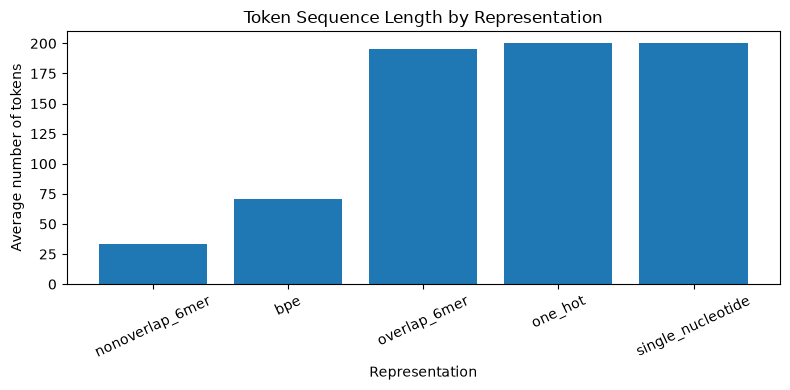

In [13]:
mean_tokens = (
    token_count_df
    .groupby("tokenizer")["token_count"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 4))
plt.bar(
    mean_tokens.index,
    mean_tokens.values,
)
plt.xlabel("Representation")
plt.ylabel("Average number of tokens")
plt.title("Token Sequence Length by Representation")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Graph 2 — Distribution of Token Counts

Most representations produce a fixed number of tokens for every 200-bp sequence.

BPE is different: token length depends on which learned chunks occur in each DNA sequence.

A box plot makes that variability visible.

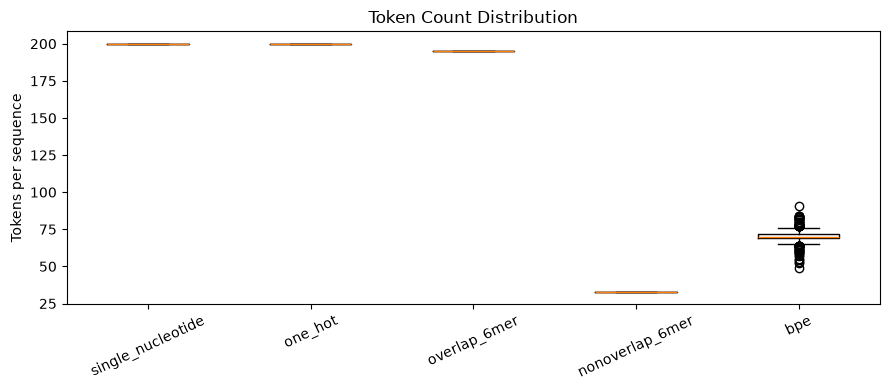

In [14]:
tokenizer_order = list(TOKENIZERS)

token_count_groups = [
    token_count_df.loc[
        token_count_df["tokenizer"] == name,
        "token_count",
    ]
    for name in tokenizer_order
]

plt.figure(figsize=(9, 4))

plt.boxplot(
    token_count_groups,
    tick_labels=tokenizer_order,
)

plt.ylabel("Tokens per sequence")
plt.title("Token Count Distribution")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Graph 3 — A Simple Attention-Compute Proxy

Self-attention compares token positions with token positions.

If a sequence contains `T` tokens, the attention-score matrix has approximately:

```text
T × T
```

entries per head.

So `T²` is a useful **conceptual compute proxy**.

It is **not an exact runtime prediction**, because real performance also depends on:

- batch size,
- model width,
- number of layers,
- hardware,
- padding,
- implementation details.

But it helps explain why sequence length matters.

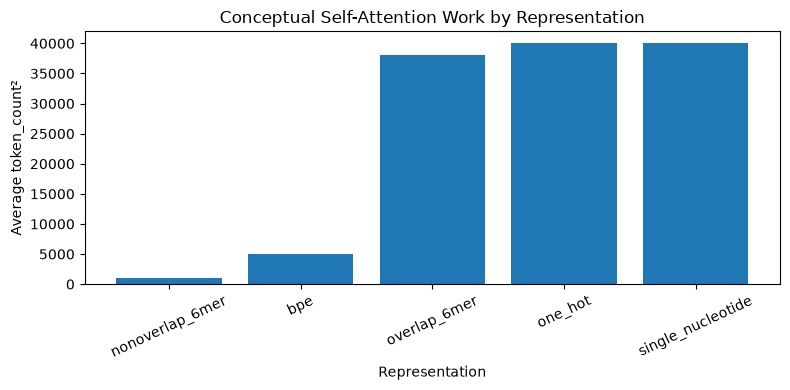

In [15]:
attention_proxy = (
    token_count_df
    .assign(
        attention_pairs=lambda x:
        x["token_count"] ** 2
    )
    .groupby("tokenizer")[
        "attention_pairs"
    ]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 4))

plt.bar(
    attention_proxy.index,
    attention_proxy.values,
)

plt.xlabel("Representation")
plt.ylabel("Average token_count²")
plt.title("Conceptual Self-Attention Work by Representation")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## BPE Exploration — What Token Lengths Did It Learn?

BPE tokens can represent one base, two bases, three bases, or longer chunks.

Let's inspect the learned vocabulary itself.

In [16]:
bpe_vocab_df = pd.DataFrame({
    "token": list(BPE_VOCAB.keys())
})

bpe_vocab_df["bases_per_token"] = (
    bpe_vocab_df["token"].apply(len)
)

bpe_vocab_df["bases_per_token"].value_counts().sort_index()

bases_per_token
1     4
2    10
3    23
4    42
5     5
Name: count, dtype: int64

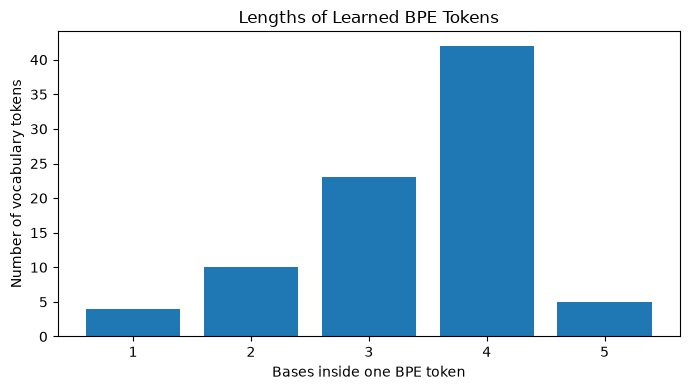

In [17]:
bpe_length_counts = (
    bpe_vocab_df[
        "bases_per_token"
    ]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))

plt.bar(
    bpe_length_counts.index.astype(str),
    bpe_length_counts.values,
)

plt.xlabel("Bases inside one BPE token")
plt.ylabel("Number of vocabulary tokens")
plt.title("Lengths of Learned BPE Tokens")
plt.tight_layout()
plt.show()

### ✅ CHECKPOINT 2

Using your graphs:

1. Which representation produces the fewest token positions?
2. Which produces the most?
3. Which representation has variable sequence length?
4. Why might non-overlapping 6-mers be computationally attractive?
5. What information does the non-overlapping implementation discard?
6. Why does fewer tokens **not** guarantee higher AUROC?

# 4. Before Attention: Learn to Read Tensor Shapes

Transformer code becomes much easier when you can read shapes.

We will use:

```text
B = batch size
T = number of token positions
C = embedding dimension
```

A Transformer input often has shape:

```text
(B, T, C)
```

Example:

```text
(2, 5, 8)
```

means:

- 2 sequences in this batch,
- 5 token positions per sequence,
- 8 numbers representing each token.

In [18]:
# 🔲 TRY IT — create a tiny fake batch
TOY_BATCH = 2
TOY_TOKENS = 5
TOY_EMBEDDING = 8

x_toy = torch.randn(
    TOY_BATCH,
    TOY_TOKENS,
    TOY_EMBEDDING,
)

print("x shape:", x_toy.shape)

x shape: torch.Size([2, 5, 8])


### ✏️ Experiment with the shape

Try changing:

```python
TOY_TOKENS = 10
```

or:

```python
TOY_EMBEDDING = 16
```

The model code is mostly transformations of tensors with predictable shapes.

# 5. Build Self-Attention Step by Step

Notebook 1 introduced:

- **Query (Q):** What am I looking for?
- **Key (K):** What do I offer?
- **Value (V):** What information do I pass along?

Now we code it.

```mermaid
flowchart TD
    A["Input x<br/>(B,T,C)"] --> B["Linear → Q"]
    A --> C["Linear → K"]
    A --> D["Linear → V"]
    B --> E["Q × Kᵀ"]
    C --> E
    E --> F["Scale"]
    F --> G["Mask padding"]
    G --> H["Softmax"]
    H --> I["Attention weights"]
    I --> J["weights × V"]
    D --> J
    J --> K["Context-aware output"]
```

## 5A. Create Q, K, and V

Each is a learned linear transformation of the same input.

If:

```text
embedding dimension = 8
head size = 4
```

then:

```text
x : (B, T, 8)
Q : (B, T, 4)
K : (B, T, 4)
V : (B, T, 4)
```

In [19]:
# 🧠 BUILD IT — Q, K, V projections
TOY_HEAD_SIZE = 4

query_layer = nn.Linear(
    TOY_EMBEDDING,
    TOY_HEAD_SIZE,
    bias=False,
)

key_layer = nn.Linear(
    TOY_EMBEDDING,
    TOY_HEAD_SIZE,
    bias=False,
)

value_layer = nn.Linear(
    TOY_EMBEDDING,
    TOY_HEAD_SIZE,
    bias=False,
)

q_toy = query_layer(x_toy)
k_toy = key_layer(x_toy)
v_toy = value_layer(x_toy)

print("x:", x_toy.shape)
print("Q:", q_toy.shape)
print("K:", k_toy.shape)
print("V:", v_toy.shape)

x: torch.Size([2, 5, 8])
Q: torch.Size([2, 5, 4])
K: torch.Size([2, 5, 4])
V: torch.Size([2, 5, 4])


## 5B. Compare Every Query with Every Key

This line:

```python
q @ k.transpose(-2, -1)
```

performs matrix multiplication.

For each sequence, it produces:

```text
(T, T)
```

attention scores.

With 5 tokens:

```text
5 × 5
```

Each row answers:

> For this query token, how strongly does it match every key token?

In [20]:
# 🧠 BUILD IT — raw attention scores
raw_scores = (
    q_toy
    @ k_toy.transpose(-2, -1)
)

print(
    "Raw score shape:",
    raw_scores.shape,
)

print("\nScore matrix for sequence 0:")
print(
    raw_scores[0].detach().round(
        decimals=2
    )
)

Raw score shape: torch.Size([2, 5, 5])

Score matrix for sequence 0:
tensor([[ 0.7000, -0.5800,  0.6000,  0.5600, -0.6000],
        [-0.1700,  0.1300,  0.1000,  0.2200, -0.0600],
        [-1.1200, -0.4200,  0.6500,  0.8100,  0.2600],
        [-0.8700,  0.8700,  1.3100,  1.5300, -0.7800],
        [ 0.1200,  0.3200, -0.7800, -0.9100,  0.4100]])


## 5C. Scale the Scores

Large vector dot products can create very large values before softmax.

Scaled dot-product attention uses the **head dimension**:

```text
1 / sqrt(head_size)
```

In Python:

```python
head_size ** -0.5
```

In [21]:
# 🧠 BUILD IT — scaled dot-product scores
scale = TOY_HEAD_SIZE ** -0.5

scaled_scores = (
    raw_scores * scale
)

print("Scale:", scale)
print(scaled_scores.shape)

Scale: 0.5
torch.Size([2, 5, 5])


## 5D. Softmax Turns Scores into Attention Weights

Softmax converts each row of scores into non-negative weights that sum to `1`.

That makes the weights easier to interpret as **how much attention is assigned across token positions**.

In [22]:
# 🧠 BUILD IT — attention weights
attention_weights = F.softmax(
    scaled_scores,
    dim=-1,
)

print(
    "One row of attention weights:"
)

print(
    attention_weights[
        0, 0
    ].detach().round(
        decimals=3
    )
)

print(
    "\nRow sum:",
    attention_weights[
        0, 0
    ].sum().item()
)

One row of attention weights:
tensor([0.2540, 0.1340, 0.2420, 0.2380, 0.1330])

Row sum: 1.0


## 5E. Use the Weights to Combine Values

The final attention output is:

```python
attention_weights @ V
```

A token's new vector becomes a weighted combination of Value vectors from relevant positions.

In [23]:
# 🧠 BUILD IT — context-aware output
attention_output = (
    attention_weights @ v_toy
)

print(
    "Attention output shape:",
    attention_output.shape,
)

Attention output shape: torch.Size([2, 5, 4])


### ✅ CHECKPOINT 3 — Reconstruct Attention

Without looking back, explain these lines:

```python
q = query(x)
k = key(x)
v = value(x)

scores = q @ k.transpose(-2, -1)
scores = scores * (head_size ** -0.5)

weights = softmax(scores)

output = weights @ v
```

If you can explain those lines, you understand the computational core of self-attention.

# 6. Turn the Steps into an Attention Head

Real batches contain sequences that may have different token counts.

We use **padding** to make a batch rectangular, plus an **attention mask**:

```text
1 = real token
0 = padding
```

The attention head must prevent padded key positions from receiving attention.

In [24]:
# 🧠 BUILD IT — one reusable self-attention head
class AttentionHead(nn.Module):

    def __init__(
        self,
        n_embd,
        head_size,
        dropout,
    ):
        super().__init__()

        self.query = nn.Linear(
            n_embd,
            head_size,
            bias=False,
        )

        self.key = nn.Linear(
            n_embd,
            head_size,
            bias=False,
        )

        self.value = nn.Linear(
            n_embd,
            head_size,
            bias=False,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.scale = (
            head_size ** -0.5
        )

    def forward(
        self,
        x,
        attention_mask,
    ):
        # 1. Create Q, K, V.
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # 2. Compare every Q with every K.
        scores = (
            q
            @ k.transpose(-2, -1)
        )

        # 3. Scale.
        scores = (
            scores * self.scale
        )

        # 4. Prevent attention to PAD key positions.
        key_mask = (
            attention_mask
            .unsqueeze(1)
        )

        scores = scores.masked_fill(
            key_mask == 0,
            float("-inf"),
        )

        # 5. Convert scores to weights.
        weights = F.softmax(
            scores,
            dim=-1,
        )

        weights = self.dropout(
            weights
        )

        # 6. Combine Value vectors.
        output = weights @ v

        return output


print("✅ AttentionHead defined.")

✅ AttentionHead defined.


In [25]:
# 🔲 TRY IT — test the class on the toy tensor
toy_mask = torch.ones(
    TOY_BATCH,
    TOY_TOKENS,
    dtype=torch.long,
)

toy_head = AttentionHead(
    n_embd=TOY_EMBEDDING,
    head_size=TOY_HEAD_SIZE,
    dropout=0.0,
)

toy_head_output = toy_head(
    x_toy,
    toy_mask,
)

print(
    "Input shape :",
    x_toy.shape,
)

print(
    "Output shape:",
    toy_head_output.shape,
)

Input shape : torch.Size([2, 5, 8])
Output shape: torch.Size([2, 5, 4])


# 7. Multi-Head Attention

One attention head produces one learned way of comparing positions.

A Transformer usually runs several heads in parallel.

```mermaid
flowchart TD
    A["Input<br/>(B,T,C)"] --> B["Head 1"]
    A --> C["Head 2"]
    A --> D["Head 3"]
    A --> E["Head 4"]
    B --> F["Concatenate"]
    C --> F
    D --> F
    E --> F
    F --> G["Output projection"]
```

If:

```text
n_embd = 32
n_head = 4
```

then each head receives:

```text
head_size = 32 / 4 = 8
```

The four 8-dimensional head outputs are concatenated back into 32 dimensions.

### Important constraint

```text
n_embd must be divisible by n_head
```

In [26]:
# 🧠 BUILD IT — multi-head attention
class MultiHeadAttention(nn.Module):

    def __init__(
        self,
        n_embd,
        n_head,
        dropout,
    ):
        super().__init__()

        assert (
            n_embd % n_head == 0
        ), (
            "n_embd must be divisible "
            "by n_head."
        )

        head_size = (
            n_embd // n_head
        )

        self.heads = nn.ModuleList([
            AttentionHead(
                n_embd,
                head_size,
                dropout,
            )
            for _ in range(n_head)
        ])

        self.projection = nn.Linear(
            n_embd,
            n_embd,
        )

        self.dropout = nn.Dropout(
            dropout
        )

    def forward(
        self,
        x,
        attention_mask,
    ):
        head_outputs = [
            head(
                x,
                attention_mask,
            )
            for head in self.heads
        ]

        combined = torch.cat(
            head_outputs,
            dim=-1,
        )

        projected = self.projection(
            combined
        )

        return self.dropout(
            projected
        )


print("✅ MultiHeadAttention defined.")

✅ MultiHeadAttention defined.


In [27]:
# ✏️ EDIT ME — explore heads and head size
TEST_N_EMBD = 32
TEST_N_HEAD = 4

assert (
    TEST_N_EMBD % TEST_N_HEAD == 0
)

print(
    "Embedding dimension:",
    TEST_N_EMBD,
)

print(
    "Number of heads:",
    TEST_N_HEAD,
)

print(
    "Dimension per head:",
    TEST_N_EMBD // TEST_N_HEAD,
)

Embedding dimension: 32
Number of heads: 4
Dimension per head: 8


# 8. Feed-Forward Network

Attention moves information **between token positions**.

After attention, a feed-forward network transforms each token representation independently.

A common pattern is:

```text
n_embd
  ↓
4 × n_embd
  ↓
activation
  ↓
n_embd
```

The temporary expansion gives the network more capacity to transform features.

In [28]:
# 🧠 BUILD IT — position-wise feed-forward network
class FeedForward(nn.Module):

    def __init__(
        self,
        n_embd,
        dropout,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                n_embd,
                4 * n_embd,
            ),
            nn.ReLU(),
            nn.Linear(
                4 * n_embd,
                n_embd,
            ),
            nn.Dropout(
                dropout
            ),
        )

    def forward(self, x):
        return self.net(x)


print("✅ FeedForward defined.")

✅ FeedForward defined.


# 9. Build One Transformer Block

Our teaching model uses a **pre-LayerNorm** block:

```mermaid
flowchart TD
    A["Input"] --> B["LayerNorm"]
    B --> C["Multi-Head Attention"]
    A --> D["+"]
    C --> D
    D --> E["LayerNorm"]
    E --> F["Feed-Forward"]
    D --> G["+"]
    F --> G
    G --> H["Output<br/>same shape"]
```

The `+` operations are **residual connections**.

Instead of replacing the original representation, a sublayer learns a useful change and adds it back.

### Why LayerNorm?

LayerNorm helps stabilize the scale of internal representations during training.

### Important architecture note

This small teaching Transformer is **not a line-for-line copy of BERT/DNABERT**. It uses a pre-LayerNorm arrangement because it is simple and stable for a from-scratch educational model.

The essential ideas—attention, multiple heads, feed-forward layers, residual connections, and normalization—are the same Transformer building blocks.

In [29]:
# 🧠 BUILD IT — one Transformer block
class TransformerBlock(nn.Module):

    def __init__(
        self,
        n_embd,
        n_head,
        dropout,
    ):
        super().__init__()

        self.attention = (
            MultiHeadAttention(
                n_embd,
                n_head,
                dropout,
            )
        )

        self.feed_forward = (
            FeedForward(
                n_embd,
                dropout,
            )
        )

        self.norm1 = nn.LayerNorm(
            n_embd
        )

        self.norm2 = nn.LayerNorm(
            n_embd
        )

    def forward(
        self,
        x,
        attention_mask,
    ):
        # Residual connection 1:
        # original x + attention update
        x = x + self.attention(
            self.norm1(x),
            attention_mask,
        )

        # Residual connection 2:
        # current x + feed-forward update
        x = x + self.feed_forward(
            self.norm2(x)
        )

        return x


print("✅ TransformerBlock defined.")

✅ TransformerBlock defined.


### ✅ CHECKPOINT 4

Explain the jobs of:

1. **Attention** — exchanges information across token positions.
2. **Multi-head attention** — learns several attention patterns in parallel.
3. **Feed-forward network** — transforms the representation at each position.
4. **Residual connection** — preserves the previous representation while adding an update.
5. **LayerNorm** — helps stabilize internal activations.

# 10. Assemble the Complete DNA Transformer

Our model needs to work with all five representations.

### Discrete token IDs

Single-nucleotide, k-mer, and BPE inputs use:

```python
nn.Embedding(vocab_size, n_embd)
```

### One-hot vectors

One-hot input already contains vectors, so we use:

```python
nn.Linear(input_dim, n_embd)
```

After that, every representation goes through the same **core Transformer architecture**.

```mermaid
flowchart TD
    A["Tokenized DNA"] --> B{"Input type?"}
    B -->|"Token IDs"| C["Embedding lookup"]
    B -->|"One-hot"| D["Linear projection"]
    C --> E["+ positional embedding"]
    D --> E
    E --> F["Transformer blocks"]
    F --> G["Final LayerNorm"]
    G --> H["Masked mean pooling"]
    H --> I["Linear classifier"]
    I --> J["Background / Binding"]
```

Unlike DNABERT, our small model does **not** use a `[CLS]` token.

Instead, we average the final vectors of the **real, non-padding tokens**.

In [30]:
# 🧠 BUILD IT — complete from-scratch DNA Transformer
class DNATransformer(nn.Module):

    def __init__(
        self,
        position_capacity,
        n_embd,
        n_head,
        n_layer,
        dropout,
        vocab_size=None,
        input_dim=None,
    ):
        super().__init__()

        # Exactly one input type must be provided.
        assert (
            (vocab_size is None)
            != (input_dim is None)
        )

        self.continuous = (
            input_dim is not None
        )

        # Token representation.
        if self.continuous:
            self.token_embedding = (
                nn.Linear(
                    input_dim,
                    n_embd,
                )
            )
        else:
            self.token_embedding = (
                nn.Embedding(
                    vocab_size,
                    n_embd,
                    padding_idx=PAD_ID,
                )
            )

        # Learned position representation.
        self.position_embedding = (
            nn.Embedding(
                position_capacity,
                n_embd,
            )
        )

        # Repeating Transformer blocks.
        self.blocks = nn.ModuleList([
            TransformerBlock(
                n_embd,
                n_head,
                dropout,
            )
            for _ in range(n_layer)
        ])

        self.final_norm = nn.LayerNorm(
            n_embd
        )

        # Binary classification head.
        self.classifier = nn.Linear(
            n_embd,
            2,
        )

    def forward(
        self,
        x,
        attention_mask,
    ):
        B, T = x.shape[:2]

        token_vectors = (
            self.token_embedding(x)
        )

        positions = torch.arange(
            T,
            device=x.device,
        )

        position_vectors = (
            self.position_embedding(
                positions
            )
        )

        h = (
            token_vectors
            + position_vectors
        )

        for block in self.blocks:
            h = block(
                h,
                attention_mask,
            )

        h = self.final_norm(h)

        # Masked mean pooling:
        # average only REAL tokens.
        mask = (
            attention_mask
            .unsqueeze(-1)
            .float()
        )

        pooled = (
            (h * mask).sum(dim=1)
            / mask.sum(dim=1).clamp(
                min=1
            )
        )

        logits = self.classifier(
            pooled
        )

        return logits


print("✅ DNATransformer defined.")

✅ DNATransformer defined.


# 11. Training Infrastructure

The next cell handles:

- variable-length tokenized sequences,
- **dynamic padding inside each batch**,
- masks,
- training,
- validation,
- metrics,
- result logging.

Dynamic padding matters here.

Suppose BPE produces:

```text
sequence A = 82 tokens
sequence B = 91 tokens
sequence C = 76 tokens
```

Within that batch, we pad only to:

```text
91 tokens
```

rather than padding everything to 200.

That makes the measured computational trade-off between representations more meaningful.

The infrastructure is hidden because the learning target here is the **Transformer architecture and experiment**, not writing a custom DataLoader from scratch.

In [31]:
# 🔒 RUN ONLY — dynamic batching, metrics, training, and saving

class TokenizedDataset(Dataset):

    def __init__(
        self,
        seqs,
        labels,
        tokenizer_info,
    ):
        self.seqs = seqs
        self.labels = labels
        self.info = tokenizer_info

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        tokens = self.info["fn"](
            self.seqs[idx]
        )

        if self.info["continuous"]:
            x = torch.tensor(
                tokens,
                dtype=torch.float32,
            )
        else:
            x = torch.tensor(
                tokens,
                dtype=torch.long,
            )

        return {
            "input": x,
            "label": torch.tensor(
                self.labels[idx],
                dtype=torch.long,
            ),
        }


def make_collate_fn(tokenizer_info):
    """
    Pad only to the longest tokenized sequence
    IN THE CURRENT BATCH.
    """

    continuous = tokenizer_info[
        "continuous"
    ]

    input_dim = tokenizer_info[
        "input_dim"
    ]

    def collate(batch):
        lengths = [
            item["input"].shape[0]
            for item in batch
        ]

        max_len = max(lengths)
        batch_size = len(batch)

        if continuous:
            x_batch = torch.zeros(
                batch_size,
                max_len,
                input_dim,
                dtype=torch.float32,
            )
        else:
            x_batch = torch.full(
                (batch_size, max_len),
                PAD_ID,
                dtype=torch.long,
            )

        attention_mask = torch.zeros(
            batch_size,
            max_len,
            dtype=torch.long,
        )

        labels = torch.empty(
            batch_size,
            dtype=torch.long,
        )

        for i, item in enumerate(batch):
            length = item[
                "input"
            ].shape[0]

            x_batch[
                i, :length
            ] = item["input"]

            attention_mask[
                i, :length
            ] = 1

            labels[i] = item["label"]

        return {
            "input": x_batch,
            "attention_mask": (
                attention_mask
            ),
            "label": labels,
        }

    return collate


def calculate_binary_metrics(
    true_labels,
    predictions,
    scores,
):
    tn, fp, fn, tp = (
        confusion_matrix(
            true_labels,
            predictions,
            labels=[0, 1],
        ).ravel()
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp)
        else np.nan
    )

    return {
        "accuracy": (
            (tp + tn)
            / (tp + tn + fp + fn)
        ),

        "precision": precision_score(
            true_labels,
            predictions,
            zero_division=0,
        ),

        "recall": recall_score(
            true_labels,
            predictions,
            zero_division=0,
        ),

        "specificity": specificity,

        "f1": f1_score(
            true_labels,
            predictions,
            zero_division=0,
        ),

        "auroc": roc_auc_score(
            true_labels,
            scores,
        ),

        "auprc": (
            average_precision_score(
                true_labels,
                scores,
            )
        ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def run_epoch(
    model,
    optimizer,
    loader,
    train,
):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    all_scores = []
    all_predictions = []
    all_true = []

    context = (
        torch.enable_grad()
        if train
        else torch.no_grad()
    )

    with context:
        for batch in loader:
            x = batch[
                "input"
            ].to(device)

            mask = batch[
                "attention_mask"
            ].to(device)

            labels = batch[
                "label"
            ].to(device)

            if train:
                optimizer.zero_grad()

            logits = model(
                x,
                mask,
            )

            loss = F.cross_entropy(
                logits,
                labels,
            )

            if train:
                loss.backward()
                optimizer.step()

            predictions = (
                logits.argmax(dim=1)
            )

            probabilities = (
                torch.softmax(
                    logits,
                    dim=1,
                )[:, 1]
            )

            total_loss += (
                loss.item()
                * labels.size(0)
            )

            total_correct += (
                predictions == labels
            ).sum().item()

            total_examples += (
                labels.size(0)
            )

            all_scores.extend(
                probabilities
                .detach()
                .cpu()
                .numpy()
            )

            all_predictions.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
            )

            all_true.extend(
                labels
                .detach()
                .cpu()
                .numpy()
            )

    return {
        "loss": (
            total_loss
            / total_examples
        ),
        "accuracy": (
            total_correct
            / total_examples
        ),
        "scores": np.asarray(
            all_scores
        ),
        "predictions": np.asarray(
            all_predictions
        ),
        "true": np.asarray(
            all_true
        ),
    }


def save_notebook2_result(
    record,
    history_df,
    predictions_df,
):
    summary_csv = (
        RESULTS_DIR
        / "notebook2_experiments.csv"
    )

    if summary_csv.exists():
        existing = pd.read_csv(
            summary_csv
        )

        existing = existing[
            existing["run_name"]
            != record["run_name"]
        ]

        combined = pd.concat(
            [
                existing,
                pd.DataFrame([record]),
            ],
            ignore_index=True,
        )
    else:
        combined = pd.DataFrame([
            record
        ])

    combined.to_csv(
        summary_csv,
        index=False,
    )

    history_df.to_csv(
        RESULTS_DIR
        / f"{record['run_name']}_history.csv",
        index=False,
    )

    predictions_df.to_csv(
        RESULTS_DIR
        / f"{record['run_name']}_predictions.csv",
        index=False,
    )

    with open(
        RESULTS_DIR
        / f"{record['run_name']}_summary.json",
        "w",
    ) as f:
        json.dump(
            record,
            f,
            indent=2,
        )


def run_transformer_experiment(
    run_name,
    tokenizer_name,
    n_embd,
    n_head,
    n_layer,
    dropout,
    batch_size,
    learning_rate,
    epochs,
    random_seed=42,
):
    """
    Train one fresh from-scratch Transformer.
    """

    assert tokenizer_name in TOKENIZERS

    assert (
        n_embd % n_head == 0
    ), (
        "n_embd must be divisible "
        "by n_head."
    )

    torch.manual_seed(
        random_seed
    )

    np.random.seed(
        random_seed
    )

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            random_seed
        )

    info = TOKENIZERS[
        tokenizer_name
    ]

    train_dataset = TokenizedDataset(
        train_seqs,
        train_labels,
        info,
    )

    val_dataset = TokenizedDataset(
        val_seqs,
        val_labels,
        info,
    )

    generator = (
        torch.Generator()
        .manual_seed(
            random_seed
        )
    )

    collate_fn = make_collate_fn(
        info
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        collate_fn=collate_fn,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )

    model = DNATransformer(
        position_capacity=info[
            "position_capacity"
        ],
        n_embd=n_embd,
        n_head=n_head,
        n_layer=n_layer,
        dropout=dropout,
        vocab_size=info[
            "vocab_size"
        ],
        input_dim=info[
            "input_dim"
        ],
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    n_params = sum(
        p.numel()
        for p in model.parameters()
    )

    history = []

    final_val = None

    print("=" * 78)
    print("RUN:", run_name)
    print("Tokenizer:", tokenizer_name)
    print(
        f"n_embd={n_embd} | "
        f"n_head={n_head} | "
        f"n_layer={n_layer} | "
        f"dropout={dropout}"
    )
    print(
        f"batch={batch_size} | "
        f"lr={learning_rate} | "
        f"epochs={epochs}"
    )
    print(
        f"parameters={n_params:,}"
    )
    print("=" * 78)

    start = time.time()

    for epoch in range(
        1,
        epochs + 1,
    ):
        epoch_start = time.time()

        train_metrics = run_epoch(
            model,
            optimizer,
            train_loader,
            train=True,
        )

        val_metrics = run_epoch(
            model,
            optimizer,
            val_loader,
            train=False,
        )

        val_auroc = roc_auc_score(
            val_metrics["true"],
            val_metrics["scores"],
        )

        val_auprc = (
            average_precision_score(
                val_metrics["true"],
                val_metrics["scores"],
            )
        )

        history.append({
            "epoch": epoch,
            "train_loss": (
                train_metrics["loss"]
            ),
            "train_accuracy": (
                train_metrics["accuracy"]
            ),
            "val_loss": (
                val_metrics["loss"]
            ),
            "val_accuracy": (
                val_metrics["accuracy"]
            ),
            "val_auroc": val_auroc,
            "val_auprc": val_auprc,
            "epoch_seconds": (
                time.time()
                - epoch_start
            ),
        })

        final_val = val_metrics

        print(
            f"Epoch {epoch}/{epochs} | "
            f"train loss={train_metrics['loss']:.4f} | "
            f"train acc={train_metrics['accuracy']:.3f} | "
            f"val loss={val_metrics['loss']:.4f} | "
            f"val acc={val_metrics['accuracy']:.3f} | "
            f"AUROC={val_auroc:.4f} | "
            f"AUPRC={val_auprc:.4f} | "
            f"{history[-1]['epoch_seconds']:.1f}s"
        )

    elapsed = (
        time.time() - start
    )

    history_df = pd.DataFrame(
        history
    )

    best_row = history_df.loc[
        history_df[
            "val_auroc"
        ].idxmax()
    ]

    final_metrics = (
        calculate_binary_metrics(
            final_val["true"],
            final_val["predictions"],
            final_val["scores"],
        )
    )

    predictions_df = val_df[
        [
            "sequence",
            "label",
            "label_name",
        ]
    ].copy()

    predictions_df[
        "predicted_label"
    ] = final_val[
        "predictions"
    ]

    predictions_df[
        "predicted_name"
    ] = predictions_df[
        "predicted_label"
    ].map({
        0: "Background",
        1: "Binding",
    })

    predictions_df[
        "binding_probability"
    ] = final_val[
        "scores"
    ]

    predictions_df[
        "correct"
    ] = (
        predictions_df["label"]
        == predictions_df[
            "predicted_label"
        ]
    )

    mean_token_count = (
        token_count_df.loc[
            token_count_df[
                "tokenizer"
            ] == tokenizer_name,
            "token_count",
        ].mean()
    )

    record = {
        "run_name": run_name,
        "tokenizer": tokenizer_name,

        "n_embd": int(n_embd),
        "n_head": int(n_head),
        "head_size": int(
            n_embd // n_head
        ),
        "n_layer": int(n_layer),
        "dropout": float(dropout),

        "batch_size": int(batch_size),
        "learning_rate": float(
            learning_rate
        ),
        "epochs": int(epochs),
        "random_seed": int(
            random_seed
        ),

        "parameters": int(n_params),
        "mean_token_count": float(
            mean_token_count
        ),

        "best_val_auroc": float(
            best_row["val_auroc"]
        ),
        "best_epoch": int(
            best_row["epoch"]
        ),

        "final_val_loss": float(
            history_df.iloc[-1][
                "val_loss"
            ]
        ),

        "final_val_accuracy": float(
            final_metrics["accuracy"]
        ),

        "final_val_precision": float(
            final_metrics["precision"]
        ),

        "final_val_recall": float(
            final_metrics["recall"]
        ),

        "final_val_specificity": float(
            final_metrics["specificity"]
        ),

        "final_val_f1": float(
            final_metrics["f1"]
        ),

        "final_val_auroc": float(
            final_metrics["auroc"]
        ),

        "final_val_auprc": float(
            final_metrics["auprc"]
        ),

        "true_negative": int(
            final_metrics["tn"]
        ),
        "false_positive": int(
            final_metrics["fp"]
        ),
        "false_negative": int(
            final_metrics["fn"]
        ),
        "true_positive": int(
            final_metrics["tp"]
        ),

        "training_time_seconds": float(
            elapsed
        ),

        "device": str(device),
    }

    save_notebook2_result(
        record,
        history_df,
        predictions_df,
    )

    print()
    print("FINAL VALIDATION METRICS")
    print("-" * 34)
    print(
        f"Accuracy    : "
        f"{record['final_val_accuracy']:.4f}"
    )
    print(
        f"Precision   : "
        f"{record['final_val_precision']:.4f}"
    )
    print(
        f"Recall      : "
        f"{record['final_val_recall']:.4f}"
    )
    print(
        f"Specificity : "
        f"{record['final_val_specificity']:.4f}"
    )
    print(
        f"F1          : "
        f"{record['final_val_f1']:.4f}"
    )
    print(
        f"AUROC       : "
        f"{record['final_val_auroc']:.4f}"
    )
    print(
        f"AUPRC       : "
        f"{record['final_val_auprc']:.4f}"
    )
    print(
        f"Training    : "
        f"{elapsed:.1f}s"
    )

    return (
        model,
        history_df,
        record,
        predictions_df,
    )


def load_notebook2_results():
    path = (
        RESULTS_DIR
        / "notebook2_experiments.csv"
    )

    if not path.exists():
        return pd.DataFrame()

    return pd.read_csv(path)


def plot_confusion_matrix(
    predictions_df,
    title="Confusion Matrix",
):
    cm = confusion_matrix(
        predictions_df["label"],
        predictions_df[
            "predicted_label"
        ],
        labels=[0, 1],
    )

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)

    plt.xticks(
        [0, 1],
        ["Background", "Binding"],
    )

    plt.yticks(
        [0, 1],
        ["Background", "Binding"],
    )

    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title(title)

    for row in range(2):
        for col in range(2):
            plt.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
            )

    plt.colorbar(
        label="Number of sequences"
    )

    plt.tight_layout()
    plt.show()


def plot_roc(
    predictions_df,
    title="ROC Curve",
):
    fpr, tpr, _ = roc_curve(
        predictions_df["label"],
        predictions_df[
            "binding_probability"
        ],
    )

    auroc = roc_auc_score(
        predictions_df["label"],
        predictions_df[
            "binding_probability"
        ],
    )

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        label=(
            f"Model "
            f"(AUROC={auroc:.3f})"
        ),
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random ranking",
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate / Recall"
    )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_precision_recall(
    predictions_df,
    title="Precision–Recall Curve",
):
    precision, recall, _ = (
        precision_recall_curve(
            predictions_df["label"],
            predictions_df[
                "binding_probability"
            ],
        )
    )

    auprc = (
        average_precision_score(
            predictions_df["label"],
            predictions_df[
                "binding_probability"
            ],
        )
    )

    positive_fraction = (
        predictions_df[
            "label"
        ].mean()
    )

    plt.figure(figsize=(6, 5))

    plt.plot(
        recall,
        precision,
        label=(
            f"Model "
            f"(AUPRC={auprc:.3f})"
        ),
    )

    plt.axhline(
        positive_fraction,
        linestyle="--",
        label=(
            "Positive fraction "
            f"= {positive_fraction:.3f}"
        ),
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


print("✅ Training infrastructure ready.")

✅ Training infrastructure ready.


# 12. Understand the Transformer Parameters Before Training

Notebook 1 focused on **fine-tuning parameters**.

Notebook 2 adds **architecture parameters** because we are building the Transformer ourselves.

## Architecture parameters

### `n_embd` — Embedding / hidden dimension

This is the width of each token representation throughout the Transformer.

Example:

```text
n_embd = 32
```

means each token is represented by **32 numbers** inside the model.

Increasing `n_embd` usually:

- increases representational capacity,
- increases parameter count,
- increases memory use,
- increases computation.

Examples:

```text
16 → small/narrow
32 → baseline
64 → wider
128 → much wider for this small teaching model
```

---

### `n_head` — Number of attention heads

Multi-head attention splits `n_embd` across several heads.

If:

```text
n_embd = 32
n_head = 4
```

then:

```text
head_size = 8
```

If:

```text
n_embd = 32
n_head = 8
```

then:

```text
head_size = 4
```

So increasing heads while holding `n_embd` fixed does **not** simply make every head bigger.

It creates **more independent attention patterns**, with fewer dimensions per head.

Constraint:

```text
n_embd % n_head == 0
```

---

### `n_layer` — Number of Transformer blocks

Each layer adds another:

```text
attention
+
feed-forward
+
normalization
+
residual connections
```

Increasing depth:

- increases parameter count,
- increases computation,
- allows more transformations,
- may improve performance,
- but can also overfit or simply waste compute.

---

### `dropout` — Regularization

Same idea as Notebook 1.

During training, dropout randomly removes a fraction of activations.

Examples:

```text
0.0 → no dropout
0.1 → moderate baseline
0.3 → stronger regularization
```

Too little may allow overfitting.

Too much may make learning difficult.

---

## Training parameters

### `learning_rate`

Controls optimizer step size.

```text
too small → very slow learning
reasonable → steady improvement
too large → unstable / overshooting
```

Because this model starts from random weights, useful learning rates can be larger than the small values often used to fine-tune a pretrained DNABERT.

Our baseline uses:

```text
1e-3 = 0.001
```

---

### `batch_size`

Examples processed before one optimizer update.

Increasing batch size:

- uses more memory,
- reduces number of updates per epoch,
- may improve GPU utilization,
- changes gradient noise.

---

### `epochs`

Number of full passes through the training set.

More epochs means:

- more optimization steps,
- more training time,
- possibly better fit,
- possibly overfitting.

---

## Representation parameter

### `tokenizer`

Changing the tokenizer can change:

- sequence length,
- vocabulary size,
- input embedding parameters,
- local context inside tokens,
- computational cost.

### Important fairness nuance

We keep the **core Transformer settings** fixed across tokenizer baselines.

However, total parameter count is not exactly identical because an ID-based tokenizer's input embedding table depends on vocabulary size.

For example, a 6-mer vocabulary needs a much larger embedding table than four single-nucleotide IDs.

That is not an error—it is part of the representation trade-off, and we will graph it.

# 13. Baseline — Same Core Transformer, Five Representations

Before tuning the architecture, compare the representations with one fixed core configuration.

```text
n_embd       = 32
n_head       = 4
n_layer      = 2
dropout      = 0.1
batch_size   = 32
learning_rate= 1e-3
epochs       = 3
```

### Predict before running

Write down:

1. Which tokenizer will have the best AUROC?
2. Which will train fastest?
3. Which will have the most parameters?
4. Which will have the fewest token positions?

Do not rewrite the prediction after seeing the results.

In [32]:
# 🔒 BASELINE — same core settings for all five
BASELINE_CONFIG = {
    "n_embd": 32,
    "n_head": 4,
    "n_layer": 2,
    "dropout": 0.1,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "epochs": 3,
    "random_seed": RANDOM_SEED,
}

BASELINE_CONFIG

{'n_embd': 32,
 'n_head': 4,
 'n_layer': 2,
 'dropout': 0.1,
 'batch_size': 32,
 'learning_rate': 0.001,
 'epochs': 3,
 'random_seed': 42}

In [33]:
# ✏️ RUN THIS — one fresh model per tokenizer
TOKENIZER_BASELINES = {}

for tokenizer_name in TOKENIZERS:

    run_name = (
        "baseline_"
        + tokenizer_name
    )

    result = run_transformer_experiment(
        run_name=run_name,
        tokenizer_name=tokenizer_name,
        **BASELINE_CONFIG,
    )

    TOKENIZER_BASELINES[
        tokenizer_name
    ] = {
        "model": result[0],
        "history": result[1],
        "record": result[2],
        "predictions": result[3],
    }

print(
    "\n✅ All tokenizer baselines finished."
)

RUN: baseline_single_nucleotide
Tokenizer: single_nucleotide
n_embd=32 | n_head=4 | n_layer=2 | dropout=0.1
batch=32 | lr=0.001 | epochs=3
parameters=31,906
Epoch 1/3 | train loss=0.6929 | train acc=0.524 | val loss=0.6850 | val acc=0.534 | AUROC=0.5653 | AUPRC=0.5515 | 1.4s
Epoch 2/3 | train loss=0.6843 | train acc=0.538 | val loss=0.6850 | val acc=0.504 | AUROC=0.5644 | AUPRC=0.5504 | 0.6s
Epoch 3/3 | train loss=0.6858 | train acc=0.562 | val loss=0.6841 | val acc=0.548 | AUROC=0.5635 | AUPRC=0.5465 | 0.6s

FINAL VALIDATION METRICS
----------------------------------
Accuracy    : 0.5482
Precision   : 0.5371
Recall      : 0.6796
Specificity : 0.4176
F1          : 0.6000
AUROC       : 0.5635
AUPRC       : 0.5465
Training    : 2.6s
RUN: baseline_one_hot
Tokenizer: one_hot
n_embd=32 | n_head=4 | n_layer=2 | dropout=0.1
batch=32 | lr=0.001 | epochs=3
parameters=31,906
Epoch 1/3 | train loss=0.6983 | train acc=0.502 | val loss=0.6919 | val acc=0.529 | AUROC=0.5495 | AUPRC=0.5585 | 0.7s
Epo

# 14. Explore the Model Results as a DataFrame

Just like Notebook 1, every training run becomes another row of data.

In [34]:
results = load_notebook2_results()

baseline_results = results[
    results["run_name"].str.startswith(
        "baseline_"
    )
].copy()

baseline_results[
    [
        "run_name",
        "tokenizer",
        "mean_token_count",
        "parameters",
        "final_val_accuracy",
        "final_val_precision",
        "final_val_recall",
        "final_val_f1",
        "best_val_auroc",
        "final_val_auprc",
        "training_time_seconds",
    ]
]

,run_name,tokenizer,mean_token_count,parameters,final_val_accuracy,final_val_precision,final_val_recall,final_val_f1,best_val_auroc,final_val_auprc,training_time_seconds
0,baseline_single_nucleotide,single_nucleotide,200.000000,31906,0.548209,0.537118,0.679558,0.600000,0.565266,0.546510,2.640531
1,baseline_one_hot,one_hot,200.000000,31906,0.542700,0.532751,0.674033,0.595122,0.564507,0.543443,2.069298
2,baseline_overlap_6mer,overlap_6mer,195.000000,162690,0.666667,0.625000,0.828729,0.712589,0.755783,0.764530,1.967621
3,baseline_nonoverlap_6mer,nonoverlap_6mer,33.000000,157506,0.528926,0.619048,0.143646,0.233184,0.608737,0.586489,1.813307
4,baseline_bpe,bpe,70.471042,34498,0.680441,0.699387,0.629834,0.662791,0.751958,0.724581,5.642780


## Graph 4 — AUROC by Tokenizer

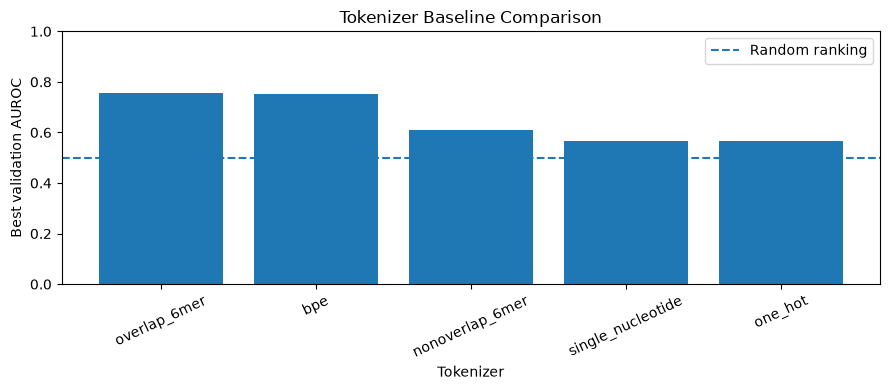

In [35]:
plot_df = (
    baseline_results
    .sort_values(
        "best_val_auroc",
        ascending=False,
    )
)

plt.figure(figsize=(9, 4))

plt.bar(
    plot_df["tokenizer"],
    plot_df["best_val_auroc"],
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random ranking",
)

plt.xlabel("Tokenizer")
plt.ylabel("Best validation AUROC")
plt.title("Tokenizer Baseline Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

## Graph 5 — Training Time by Tokenizer

This graph connects the tokenization discussion to actual measured runtime.

Remember: runtime depends on the current machine and environment. It is an **empirical measurement**, not a permanent property of a tokenizer.

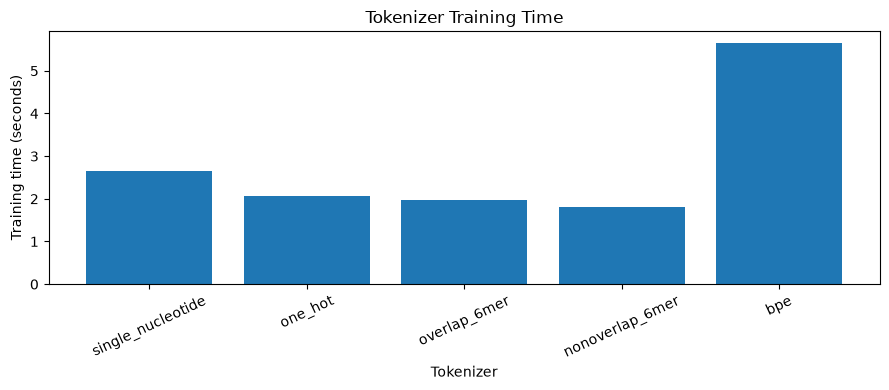

In [36]:
plt.figure(figsize=(9, 4))

plt.bar(
    baseline_results["tokenizer"],
    baseline_results[
        "training_time_seconds"
    ],
)

plt.xlabel("Tokenizer")
plt.ylabel("Training time (seconds)")
plt.title("Tokenizer Training Time")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Graph 6 — Model Parameter Count

The same core Transformer can still have different total parameter counts because vocabulary size changes the input embedding table.

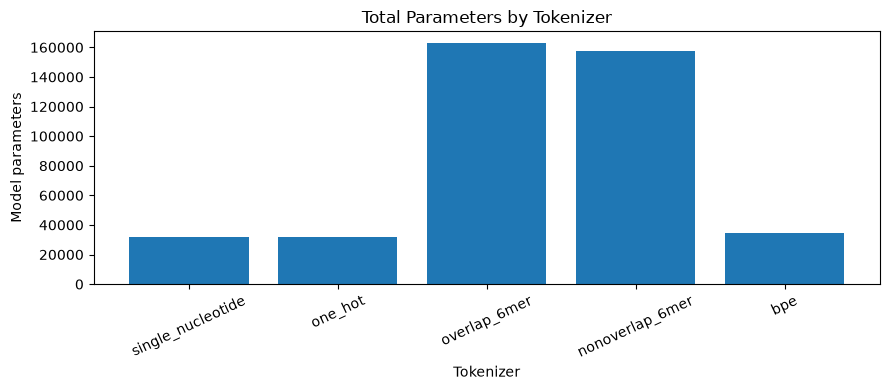

In [37]:
plt.figure(figsize=(9, 4))

plt.bar(
    baseline_results["tokenizer"],
    baseline_results["parameters"],
)

plt.xlabel("Tokenizer")
plt.ylabel("Model parameters")
plt.title("Total Parameters by Tokenizer")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Graph 7 — Token Count vs. Training Time

This asks:

> Do representations with more token positions tend to take longer in our experiment?

This is a **relationship**, so a scatter plot is useful.

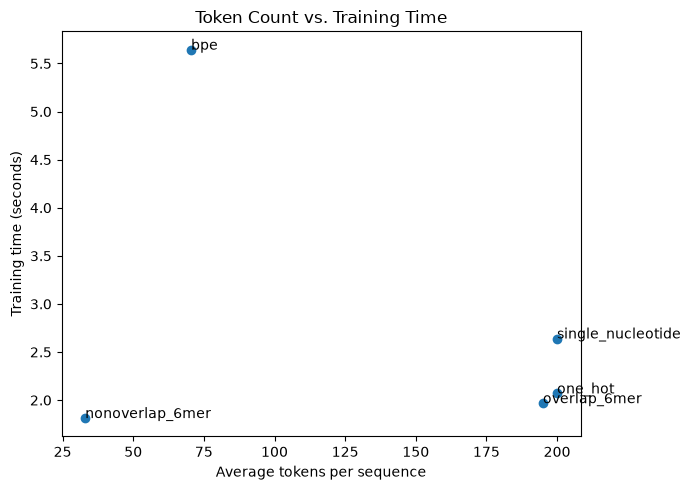

In [38]:
plt.figure(figsize=(7, 5))

plt.scatter(
    baseline_results[
        "mean_token_count"
    ],
    baseline_results[
        "training_time_seconds"
    ],
)

for _, row in baseline_results.iterrows():
    plt.annotate(
        row["tokenizer"],
        (
            row[
                "mean_token_count"
            ],
            row[
                "training_time_seconds"
            ],
        ),
    )

plt.xlabel("Average tokens per sequence")
plt.ylabel("Training time (seconds)")
plt.title("Token Count vs. Training Time")
plt.tight_layout()
plt.show()

## Graph 8 — AUROC vs. Training Time

A model can be more accurate but more expensive.

This plot helps visualize a **performance / compute trade-off**.

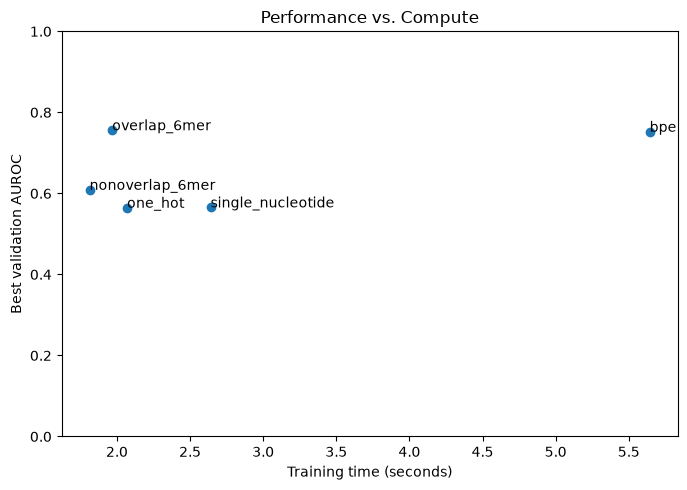

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(
    baseline_results[
        "training_time_seconds"
    ],
    baseline_results[
        "best_val_auroc"
    ],
)

for _, row in baseline_results.iterrows():
    plt.annotate(
        row["tokenizer"],
        (
            row[
                "training_time_seconds"
            ],
            row[
                "best_val_auroc"
            ],
        ),
    )

plt.xlabel("Training time (seconds)")
plt.ylabel("Best validation AUROC")
plt.title("Performance vs. Compute")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Graph 9 — Compare Any Validation Metric

The same graph pattern can compare:

- accuracy,
- precision,
- recall,
- specificity,
- F1,
- AUROC,
- AUPRC.

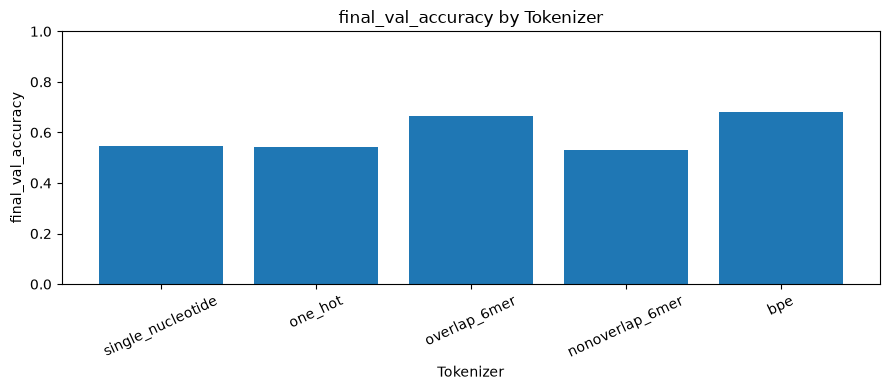

In [40]:
# ✏️ EDIT ME
METRIC_TO_COMPARE = "final_val_accuracy"

metric_columns = [
    "final_val_accuracy",
    "final_val_precision",
    "final_val_recall",
    "final_val_specificity",
    "final_val_f1",
    "best_val_auroc",
    "final_val_auprc",
]

assert (
    METRIC_TO_COMPARE
    in metric_columns
)

plt.figure(figsize=(9, 4))

plt.bar(
    baseline_results["tokenizer"],
    baseline_results[
        METRIC_TO_COMPARE
    ],
)

plt.xlabel("Tokenizer")
plt.ylabel(METRIC_TO_COMPARE)
plt.title(
    f"{METRIC_TO_COMPARE} by Tokenizer"
)
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 15. Inspect One Tokenizer in More Detail

Aggregate graphs compare models.

Now choose one tokenizer and inspect:

- training vs validation loss,
- training vs validation accuracy,
- confusion matrix,
- ROC curve,
- precision–recall curve,
- individual mistakes.

This is the same evaluation vocabulary you learned in Notebook 1.

In [41]:
# ✏️ EDIT ME
TOKENIZER_TO_INSPECT = "overlap_6mer"

assert (
    TOKENIZER_TO_INSPECT
    in TOKENIZER_BASELINES
)

chosen = TOKENIZER_BASELINES[
    TOKENIZER_TO_INSPECT
]

chosen_history = chosen[
    "history"
]

chosen_predictions = chosen[
    "predictions"
]

chosen_record = chosen[
    "record"
]

chosen_record

{'run_name': 'baseline_overlap_6mer',
 'tokenizer': 'overlap_6mer',
 'n_embd': 32,
 'n_head': 4,
 'head_size': 8,
 'n_layer': 2,
 'dropout': 0.1,
 'batch_size': 32,
 'learning_rate': 0.001,
 'epochs': 3,
 'random_seed': 42,
 'parameters': 162690,
 'mean_token_count': 195.0,
 'best_val_auroc': 0.755782891142007,
 'best_epoch': 3,
 'final_val_loss': 0.6032352265247629,
 'final_val_accuracy': 0.6666666666666666,
 'final_val_precision': 0.625,
 'final_val_recall': 0.8287292817679558,
 'final_val_specificity': 0.5054945054945055,
 'final_val_f1': 0.7125890736342043,
 'final_val_auroc': 0.755782891142007,
 'final_val_auprc': 0.7645295551205846,
 'true_negative': 92,
 'false_positive': 90,
 'false_negative': 31,
 'true_positive': 150,
 'training_time_seconds': 1.9676213264465332,
 'device': 'cuda'}

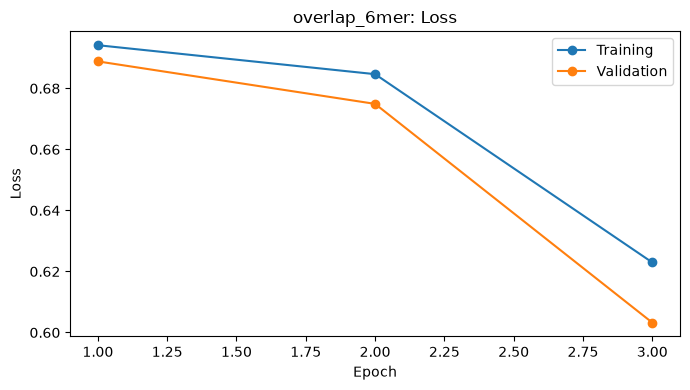

In [42]:
# 👀 READ — loss curves
plt.figure(figsize=(7, 4))

plt.plot(
    chosen_history["epoch"],
    chosen_history["train_loss"],
    marker="o",
    label="Training",
)

plt.plot(
    chosen_history["epoch"],
    chosen_history["val_loss"],
    marker="o",
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    f"{TOKENIZER_TO_INSPECT}: Loss"
)
plt.legend()
plt.tight_layout()
plt.show()

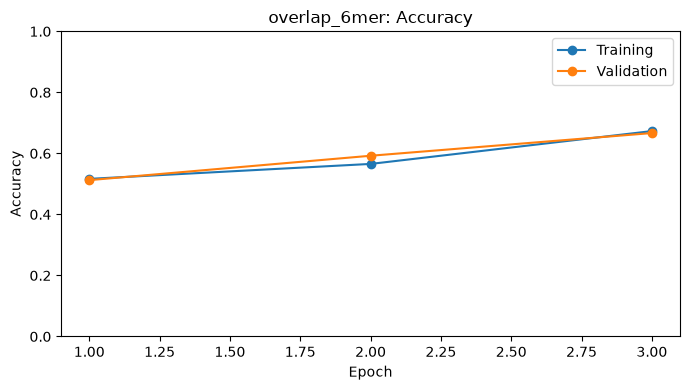

In [43]:
# 👀 READ — accuracy curves
plt.figure(figsize=(7, 4))

plt.plot(
    chosen_history["epoch"],
    chosen_history[
        "train_accuracy"
    ],
    marker="o",
    label="Training",
)

plt.plot(
    chosen_history["epoch"],
    chosen_history[
        "val_accuracy"
    ],
    marker="o",
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    f"{TOKENIZER_TO_INSPECT}: Accuracy"
)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

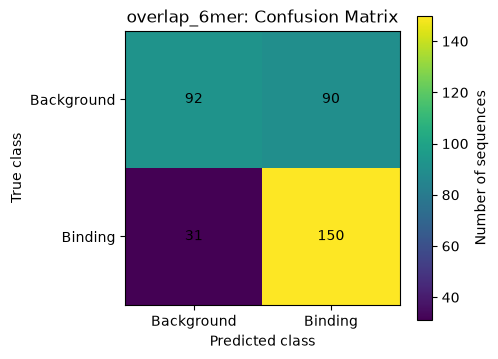

In [44]:
# 👀 READ — confusion matrix
plot_confusion_matrix(
    chosen_predictions,
    title=(
        f"{TOKENIZER_TO_INSPECT}: "
        "Confusion Matrix"
    ),
)

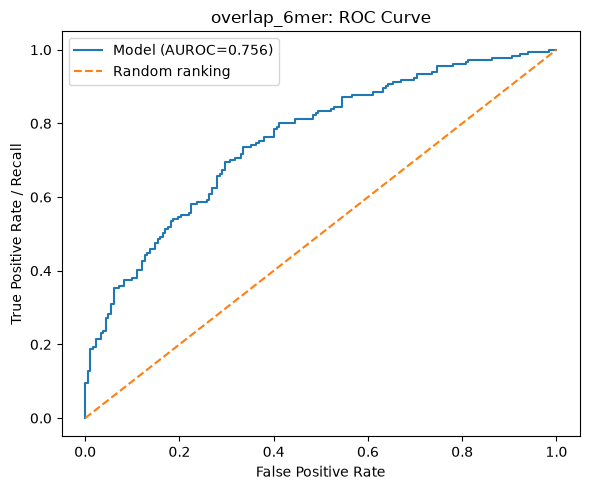

In [45]:
# 👀 READ — ROC curve
plot_roc(
    chosen_predictions,
    title=(
        f"{TOKENIZER_TO_INSPECT}: "
        "ROC Curve"
    ),
)

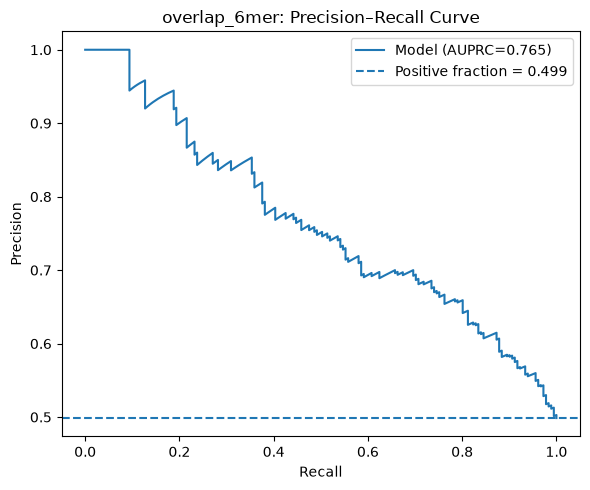

In [46]:
# 👀 READ — precision–recall curve
plot_precision_recall(
    chosen_predictions,
    title=(
        f"{TOKENIZER_TO_INSPECT}: "
        "Precision–Recall Curve"
    ),
)

In [47]:
# 🔲 TRY IT — inspect model mistakes
chosen_predictions[
    chosen_predictions["correct"] == False
].sort_values(
    "binding_probability",
    ascending=False,
).head(10)

,sequence,label,label_name,predicted_label,predicted_name,binding_probability,correct
164,ATCCATCCCCTTGGGAAACGCCCCTGAGGTATCTATCAGGTGTAGT...,0,Background,1,Binding,0.871459,False
270,TCAATTTCATTCGATGATGATTCCATTCCATGATTCCATTTGATTC...,0,Background,1,Binding,0.859148,False
254,ATGACTGCAGTAGTTTCCCAGCGATGATTCTTAACCTGGCTGAAAT...,0,Background,1,Binding,0.845229,False
176,GTATCATTCAAACAAAATTGCTTCATACTATAAGGGTCATTTCAAA...,0,Background,1,Binding,0.835571,False
248,CCCTTTGGGGGAAATTTGTTTTTGAGACTTACCCATGTGAGTGTAT...,0,Background,1,Binding,0.824872,False
58,GCAGCAGGAAGGAAGCTGGGGCGGAGCAGGCCCTGGGAAGGACCAA...,0,Background,1,Binding,0.822834,False
281,AGTAACCAAAACAGCATGGTACTGGTACCAAAACACAGATATAGAT...,0,Background,1,Binding,0.819111,False
317,AGTGGAAATTTAAAACAATCTATACCCTTAAACGTGAGTATATTAT...,0,Background,1,Binding,0.815719,False
333,GACCATGTCTTTAAATATAGATAGACAGATAGAAAGATATCTGTCT...,0,Background,1,Binding,0.807462,False
46,CATTCCTCCCCACACTCATCGCCCTTACCACGCTACTCCTACCTAT...,0,Background,1,Binding,0.800935,False


### ✅ CHECKPOINT 5

Use the actual results to answer:

1. Which tokenizer had the highest AUROC?
2. Which trained fastest?
3. Which had the most model parameters?
4. Did shorter token sequences always train faster?
5. Did the fastest tokenizer also perform best?
6. Did single-nucleotide and one-hot behave identically?
7. How did overlapping and non-overlapping 6-mers differ?
8. What kinds of errors did your selected model make?

# 16. Your Architecture Experiment

You now have a controlled tokenizer baseline.

Next, keep **one tokenizer fixed** and change **one model/training parameter first**.

Possible questions:

### Depth

```text
n_layer = 1, 2, 4
```

### Width

```text
n_embd = 16, 32, 64
```

### Number of attention heads

```text
n_head = 1, 2, 4, 8
```

Remember:

```text
n_embd must be divisible by n_head
```

### Dropout

```text
0.0, 0.1, 0.3
```

### Learning rate

```text
3e-4, 1e-3, 3e-3
```

### Batch size

```text
16, 32, 64
```

### Epochs

```text
2, 3, 5
```

For your first architecture experiment, change **one** parameter.

Notebook 3 will later let you scale to larger/more expensive configurations.

## Predict First

Before running:

1. **Independent variable:** What are you changing?
2. **Controls:** What are you keeping the same?
3. What do you predict will happen to AUROC?
4. What do you predict will happen to runtime?
5. What do you predict will happen to parameter count?

In [48]:
# ✏️ EDIT ME — change ONE value first
EXPERIMENT_CONFIG = {
    "run_name": "experiment_1",

    # Keep one tokenizer fixed.
    "tokenizer_name": "overlap_6mer",

    # Architecture:
    "n_embd": 32,
    "n_head": 4,
    "n_layer": 4,
    "dropout": 0.1,

    # Training:
    "batch_size": 32,
    "learning_rate": 1e-3,
    "epochs": 3,

    "random_seed": RANDOM_SEED,
}

EXPERIMENT_CONFIG

{'run_name': 'experiment_1',
 'tokenizer_name': 'overlap_6mer',
 'n_embd': 32,
 'n_head': 4,
 'n_layer': 4,
 'dropout': 0.1,
 'batch_size': 32,
 'learning_rate': 0.001,
 'epochs': 3,
 'random_seed': 42}

In [49]:
# ✏️ RUN THIS after making your prediction
(
    experiment_model,
    experiment_history,
    experiment_record,
    experiment_predictions,
) = run_transformer_experiment(
    **EXPERIMENT_CONFIG
)

RUN: experiment_1
Tokenizer: overlap_6mer
n_embd=32 | n_head=4 | n_layer=4 | dropout=0.1
batch=32 | lr=0.001 | epochs=3
parameters=187,906
Epoch 1/3 | train loss=0.7022 | train acc=0.509 | val loss=0.6882 | val acc=0.573 | AUROC=0.6065 | AUPRC=0.6312 | 1.1s
Epoch 2/3 | train loss=0.6875 | train acc=0.516 | val loss=0.6829 | val acc=0.515 | AUROC=0.6916 | AUPRC=0.7008 | 1.1s
Epoch 3/3 | train loss=0.6175 | train acc=0.666 | val loss=0.6097 | val acc=0.680 | AUROC=0.7440 | AUPRC=0.7476 | 1.1s

FINAL VALIDATION METRICS
----------------------------------
Accuracy    : 0.6804
Precision   : 0.6484
Recall      : 0.7845
Specificity : 0.5769
F1          : 0.7100
AUROC       : 0.7440
AUPRC       : 0.7476
Training    : 3.3s


# 17. Explore All Your Notebook 2 Experiments

Every run is saved to:

```text
~/notebook2_results/notebook2_experiments.csv
```

That means parameter tuning creates a new dataset you can explore with pandas.

In [50]:
results = load_notebook2_results()

results[
    [
        "run_name",
        "tokenizer",
        "n_embd",
        "n_head",
        "head_size",
        "n_layer",
        "dropout",
        "batch_size",
        "learning_rate",
        "epochs",
        "parameters",
        "best_val_auroc",
        "final_val_accuracy",
        "final_val_f1",
        "training_time_seconds",
    ]
]

,run_name,tokenizer,n_embd,n_head,head_size,n_layer,dropout,batch_size,learning_rate,epochs,parameters,best_val_auroc,final_val_accuracy,final_val_f1,training_time_seconds
0,baseline_single_nucleotide,single_nucleotide,32,4,8,2,0.1,32,0.001,3,31906,0.565266,0.548209,0.600000,2.640531
1,baseline_one_hot,one_hot,32,4,8,2,0.1,32,0.001,3,31906,0.564507,0.542700,0.595122,2.069298
2,baseline_overlap_6mer,overlap_6mer,32,4,8,2,0.1,32,0.001,3,162690,0.755783,0.666667,0.712589,1.967621
3,baseline_nonoverlap_6mer,nonoverlap_6mer,32,4,8,2,0.1,32,0.001,3,157506,0.608737,0.528926,0.233184,1.813307
4,baseline_bpe,bpe,32,4,8,2,0.1,32,0.001,3,34498,0.751958,0.680441,0.662791,5.642780
5,experiment_1,overlap_6mer,32,4,8,4,0.1,32,0.001,3,187906,0.744035,0.680441,0.710000,3.256268


## Reusable Graph — Parameter vs. AUROC

Choose a parameter that actually varies across the runs you want to compare.

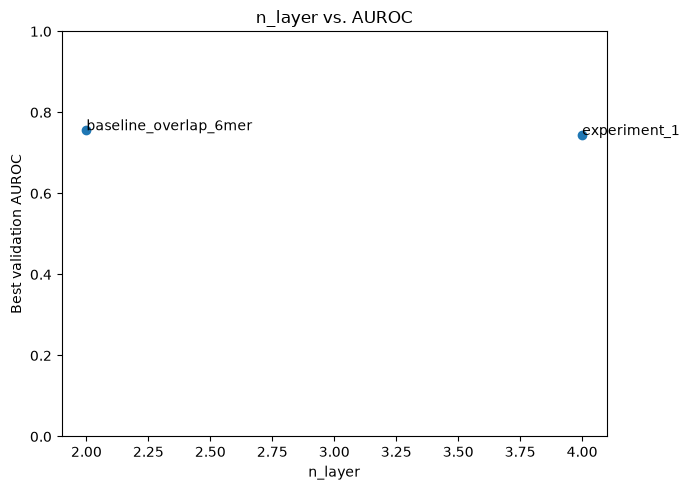

In [51]:
# ✏️ EDIT ME
TOKENIZER_FOR_PLOT = "overlap_6mer"
PARAMETER_TO_PLOT = "n_layer"

parameter_choices = [
    "n_embd",
    "n_head",
    "n_layer",
    "dropout",
    "batch_size",
    "learning_rate",
    "epochs",
    "parameters",
]

assert (
    PARAMETER_TO_PLOT
    in parameter_choices
)

plot_df = results[
    results["tokenizer"]
    == TOKENIZER_FOR_PLOT
].copy()

plot_df = plot_df.sort_values(
    PARAMETER_TO_PLOT
)

plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df[
        PARAMETER_TO_PLOT
    ],
    plot_df[
        "best_val_auroc"
    ],
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["run_name"],
        (
            row[
                PARAMETER_TO_PLOT
            ],
            row[
                "best_val_auroc"
            ],
        ),
    )

plt.xlabel(PARAMETER_TO_PLOT)
plt.ylabel("Best validation AUROC")
plt.title(
    f"{PARAMETER_TO_PLOT} vs. AUROC"
)
plt.ylim(0, 1)

if (
    PARAMETER_TO_PLOT
    == "learning_rate"
):
    plt.xscale("log")

plt.tight_layout()
plt.show()

## Reusable Graph — Parameter vs. Runtime

The same experiment can have a **performance question** and a **compute question**.

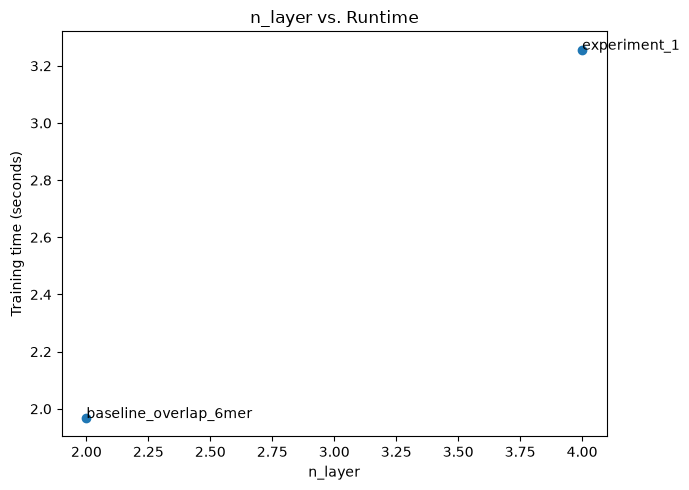

In [52]:
plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df[
        PARAMETER_TO_PLOT
    ],
    plot_df[
        "training_time_seconds"
    ],
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["run_name"],
        (
            row[
                PARAMETER_TO_PLOT
            ],
            row[
                "training_time_seconds"
            ],
        ),
    )

plt.xlabel(PARAMETER_TO_PLOT)
plt.ylabel("Training time (seconds)")
plt.title(
    f"{PARAMETER_TO_PLOT} vs. Runtime"
)

if (
    PARAMETER_TO_PLOT
    == "learning_rate"
):
    plt.xscale("log")

plt.tight_layout()
plt.show()

# 18. How to Make a New Graph Yourself

The graphing recipe from Notebook 1 still applies.

## Categories → bar graph

```python
plt.bar(
    results["tokenizer"],
    results["best_val_auroc"]
)
```

## Training across epochs → line graph

```python
plt.plot(
    history["epoch"],
    history["val_loss"]
)
```

## Numeric relationship → scatter plot

```python
plt.scatter(
    results["parameters"],
    results["training_time_seconds"]
)
```

Then always add:

```python
plt.xlabel(...)
plt.ylabel(...)
plt.title(...)
plt.tight_layout()
plt.show()
```

### Questions you can now ask

- Does a wider model improve AUROC?
- Does a deeper model take longer?
- Do more parameters always improve validation performance?
- Is training time related to token count?
- Does dropout change the gap between training and validation?
- Does increasing heads help when `n_embd` is fixed?
- Which tokenizer gives the best performance/runtime trade-off?

You are no longer limited to the graphs already written in the notebook.

# 19. What Is Different from DNABERT?

You now built a Transformer yourself—but it is not the same experiment as Notebook 1.

| From-scratch Transformer | DNABERT |
|---|---|
| random initial weights | pretrained DNA weights |
| small teaching architecture | much larger pretrained architecture |
| learns only from our CTCF dataset | learned DNA patterns before seeing CTCF labels |
| tokenizer is an experimental variable | 6-mer tokenizer is tied to its pretraining |
| masked mean pooling | `[CLS]` classification representation |
| pre-LayerNorm teaching block | BERT-family architecture details differ |

Therefore:

> If DNABERT has higher AUROC than the custom model, we cannot conclude that the difference is caused only by tokenizer choice.

Many variables differ simultaneously.

Notebook 3 will give us HPC tools to push **both approaches** harder and compare the resulting experiments more carefully.

# 20. Notebook 2 Summary

You have now built the complete pipeline:

```mermaid
flowchart LR
    A["DNA"] --> B["Tokenizer"]
    B --> C["Token representation"]
    C --> D["+ position"]
    D --> E["Q / K / V"]
    E --> F["Multi-Head Attention"]
    F --> G["Feed-Forward"]
    G --> H["Transformer Blocks"]
    H --> I["Masked Mean Pooling"]
    I --> J["Classifier"]
    J --> K["Binding / Background"]
```

### The essential code you should recognize

```python
q = query(x)
k = key(x)
v = value(x)

scores = q @ k.transpose(-2, -1)
scores = scores * (head_size ** -0.5)

weights = softmax(scores)

attention_output = weights @ v
```

and:

```python
x = x + attention(layer_norm(x))
x = x + feed_forward(layer_norm(x))
```

You do not need to memorize every PyTorch constructor.

You should be able to explain **what these lines accomplish and how they fit together**.

# 📚 Mini Glossary

| Term | Meaning |
|---|---|
| **Tokenization** | Rule for splitting/representing a sequence before modeling |
| **Vocabulary** | Distinct discrete tokens that can receive IDs |
| **One-hot vector** | Fixed binary vector identifying a category/base |
| **BPE** | Learns frequent adjacent chunks from training data |
| **Padding** | Extra positions used to make tensors in a batch the same length |
| **Attention mask** | Marks real tokens vs padding |
| **Embedding dimension (`n_embd`)** | Width of each internal token representation |
| **Attention head** | One learned Q/K/V attention calculation |
| **Head size** | `n_embd / n_head` in this implementation |
| **Multi-head attention** | Several attention heads operating in parallel |
| **Feed-forward network** | Per-position neural transformation after attention |
| **Residual connection** | Adds the previous representation back to a sublayer output |
| **LayerNorm** | Normalizes internal features to help stabilize training |
| **Transformer block** | Attention + feed-forward + residuals + normalization |
| **`n_layer`** | Number of Transformer blocks |
| **Masked mean pooling** | Average only the real final token vectors |
| **Parameter count** | Number of learned scalar values in the model |
| **Dynamic padding** | Pad each batch only to its longest current sequence |
| **Controlled experiment** | Change one factor while keeping other important factors fixed |

# ✅ End of Notebook 2

You moved from:

> **“I can fine-tune a Transformer.”**

to:

> **“I can explain and code the essential pieces of a Transformer, train it with different DNA representations, and investigate how architecture, representation, performance, and computation interact.”**

Notebook 3 will use SLURM/HPC to run **larger and more numerous experiments** for both DNABERT and your custom Transformer.